In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [46]:
df = pd.read_csv("WineQT.csv")

print(df.head())
print("Duplicate vals:", df.duplicated().sum())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [32]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [47]:
X = df.drop(columns=["quality"])
y = df["quality"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=11,
    test_size=0.35
)

In [49]:
scaler = MinMaxScaler(feature_range=(0, 1))

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [50]:
KNN = KNeighborsClassifier(n_neighbors=5)


In [51]:
KNN.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](6,)","[3,4,5,6,7,8]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [52]:
y_pred = KNN.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[5 6 7 6 6 5 5 6 5 5 5 6 5 5 7 7 6 5 5 5 6 5 6 5 6 6 6 5 6 6 6 6 6 5 6 7 5
 6 5 6 5 5 7 5 6 6 5 6 5 5 5 6 5 5 5 6 6 6 5 5 6 5 5 6 5 5 5 6 6 7 7 5 5 6
 6 6 5 6 6 6 7 6 5 5 5 5 6 5 5 6 5 5 5 5 5 5 6 5 5 6 5 6 5 5 5 5 6 6 6 7 6
 5 6 7 5 6 5 5 6 6 6 6 6 6 6 5 5 5 6 4 5 7 6 6 5 5 5 6 7 7 6 5 6 6 5 5 5 6
 6 7 6 7 5 5 5 6 5 6 6 6 6 6 5 6 6 5 5 6 7 6 6 5 6 6 6 5 5 6 5 6 5 5 5 5 5
 5 6 5 5 6 7 7 5 6 5 5 5 5 6 7 6 6 7 5 6 5 6 5 6 6 5 5 6 5 5 5 7 6 6 6 6 6
 6 6 5 6 6 5 6 5 6 6 6 6 5 6 5 5 6 6 5 6 5 5 6 6 6 6 6 5 6 6 5 5 5 5 6 6 5
 5 6 5 5 5 6 7 7 5 5 6 6 5 5 5 5 5 5 7 7 6 5 6 5 5 5 5 6 6 5 6 5 7 5 6 6 5
 6 5 6 5 5 5 5 6 5 5 7 6 5 5 5 6 7 5 5 5 5 6 6 5 6 5 6 5 6 7 5 6 6 5 5 5 6
 5 7 5 6 7 5 5 6 5 5 6 5 5 5 6 6 5 5 5 6 7 6 5 5 6 5 6 7 6 6 5 6 6 5 5 6 7
 6 5 5 6 5 6 6 6 7 5 7 5 6 4 5 6 6 7 6 6 5 6 7 5 6 5 5 5 5 5 6]


In [40]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier(n_neighbors=8)

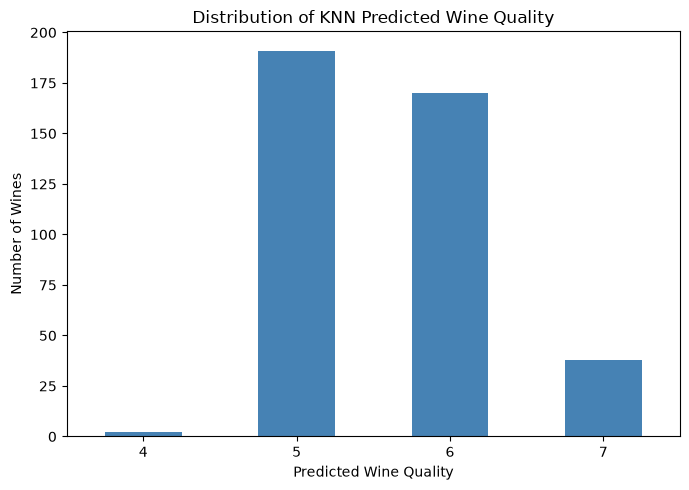

In [55]:
prediction_counts = pd.Series(y_pred).value_counts().sort_index()

plt.figure(figsize=(7, 5))
prediction_counts.plot(kind="bar", color="steelblue")

plt.xlabel("Predicted Wine Quality")
plt.ylabel("Number of Wines")
plt.title("Distribution of KNN Predicted Wine Quality")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

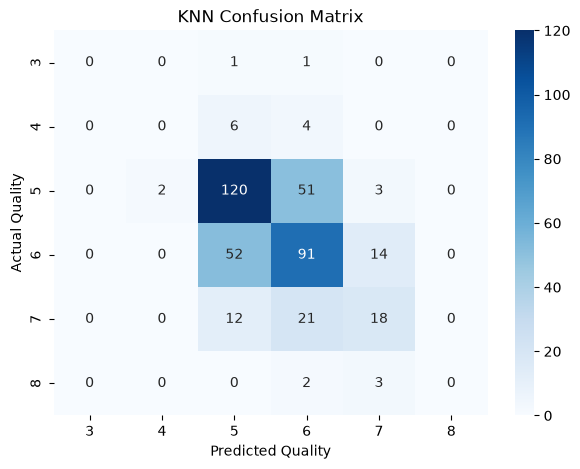

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")
plt.title("KNN Confusion Matrix")
plt.show()


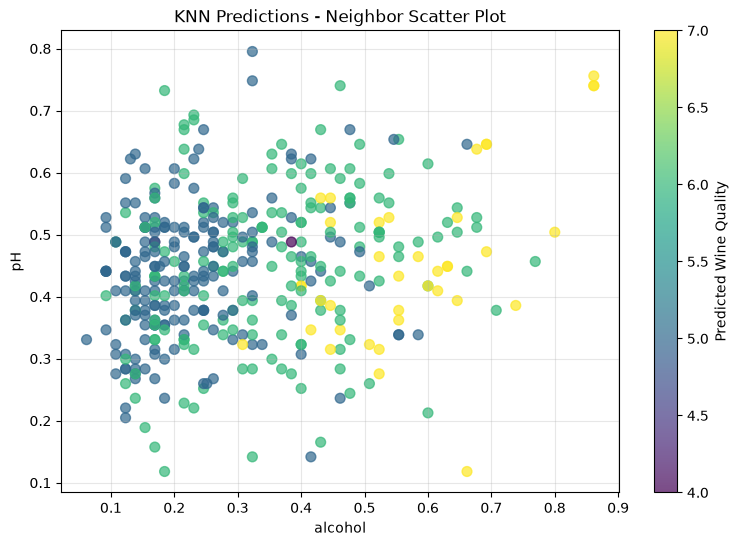

In [59]:
import matplotlib.pyplot as plt

feature1 = "alcohol"
feature2 = "pH"

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_test[:, X.columns.get_loc(feature1)],
    X_test[:, X.columns.get_loc(feature2)],
    c=y_pred,
    cmap="viridis",
    s=50,
    alpha=0.7
)

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title("KNN Predictions - Neighbor Scatter Plot")

plt.colorbar(scatter, label="Predicted Wine Quality")

plt.grid(alpha=0.3)
plt.show()
